### Read the Snow17 and SNOWPACK Test1/ Output and Compare with Obs 

Notebook contents 
* we have test simulations of from SNOWPACK at Powder Patch with HRRR forcing from WY2024. Let's read and compare with obs 
* and for Snow17 too

created by Cassie Lumbrazo\
last updated: Feb 2026\
run location: UAS linux\
python environment: **xarray**

In [1]:
# import packages 
%matplotlib inline

# plotting packages 
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns 

sns.set_theme()
# plt.rcParams['figure.figsize'] = [12,6] #overriding size

# data packages 
import pandas as pd
import numpy as np
import xarray as xr
from datetime import datetime

import scipy
import os

In [2]:
# set some seaborn plotting constants so that all plots look the same
sns.set_theme()
plt.rcParams['figure.figsize'] = [12,6] #overriding size

In [3]:
pwd

'/home/cassie/python/repos/snow_model_output'

# Function for Reading SMET Files 

In [4]:
def read_smet(filepath):
    header = {}
    fields = None
    data_start = None

    # Read file and parse header
    with open(filepath, "r") as f:
        lines = f.readlines()

    for i, line in enumerate(lines):
        line = line.strip()

        # Detect fields line
        if line.startswith("fields"):
            fields = line.split("=")[1].strip().split()

        # Detect start of data
        if line == "[DATA]":
            data_start = i + 1
            break

        # Parse header key-value pairs
        if "=" in line and not line.startswith("["):
            key, value = line.split("=", 1)
            header[key.strip()] = value.strip()

    if fields is None:
        raise ValueError("No 'fields' line found in SMET header.")
    if data_start is None:
        raise ValueError("No [DATA] section found.")

    # Read data into DataFrame
    df = pd.read_csv(
        filepath,
        skiprows=data_start,
        delim_whitespace=True,
        names=fields,
        parse_dates=["timestamp"]
    )

    # Set timestamp as index
    df = df.set_index("timestamp")

    # Convert to xarray
    ds = xr.Dataset.from_dataframe(df)

    return ds, header

In [5]:
ds_snowpack, header = read_smet("/home/cassie/python/models/run_snowpack/test1/output/HRRR_POINT_precip_accum_in_smet.smet")

print(ds_snowpack)
print(header)

<xarray.Dataset> Size: 2MB
Dimensions:               (timestamp: 2967)
Coordinates:
  * timestamp             (timestamp) datetime64[ns] 24kB 2023-10-01T05:00:00...
Data variables: (12/63)
    Qs                    (timestamp) float64 24kB 340.2 317.9 ... 10.84 3.142
    Ql                    (timestamp) float64 24kB 331.3 309.2 ... 5.348 0.417
    Qg                    (timestamp) float64 24kB 0.0 0.0 0.0 ... 0.0 0.0 0.0
    TSG                   (timestamp) float64 24kB 0.0 0.0 0.0 ... 0.0 0.0 0.0
    Qg0                   (timestamp) float64 24kB -999.0 -999.0 ... 0.0 0.0
    Qr                    (timestamp) float64 24kB 8.188 4.834 3.698 ... 0.0 0.0
    ...                    ...
    zSs                   (timestamp) float64 24kB 0.0 0.0 0.0 ... 119.8 119.8
    Ss                    (timestamp) float64 24kB 6.0 6.0 6.0 ... 0.05 0.05
    zS4                   (timestamp) float64 24kB 0.0 0.0 0.0 ... 119.8 119.8
    S4                    (timestamp) float64 24kB 6.0 6.0 6.0 ... 1.05

/tmp/ipykernel_1515130/1183788903.py:33: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(


Open Obs Data at Powder Patch

In [6]:
# download mesonet data as well to plot this with the Mesowest data...
filename = '/home/cassie/data/fishcreek/mesonet/rawdata/PowderPatch_everything_until_1June2025.txt'
df_met = pd.read_csv(filename, sep = ",")

# make utc_valid a datetime and index the df_met by it 
df_met['datetime'] = pd.to_datetime(df_met['utc_valid'], utc=True)
df_met = df_met.set_index('datetime')
df_met.head()

df_met.head()

,station,utc_valid,PCIRZZ,PCIRZZZ,RNIRZZ,SDIRZZ,SDIRZZZ,TAIRZZ,TAIRZZZ,UDIRZZ,UHIRZZZ,UPIRZZ,UPIRZZZ,USIRZZ,USIRZZZ,VBIRZZ,VBIRZZZ,XRIRZZ,XRIRZZZ
datetime,,,,,,,,,,,,,,,,,,,
2010-12-15 22:00:00+00:00,PPSA2,2010-12-15 22:00:00,NaN,NaN,0.0,35.0,NaN,18.0,NaN,170.0,NaN,NaN,NaN,1.790,NaN,NaN,NaN,80.20,NaN
2011-01-09 04:15:00+00:00,PPSA2,2011-01-09 04:15:00,NaN,NaN,NaN,55.0,NaN,22.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,71.00,NaN
2011-05-21 03:45:00+00:00,PPSA2,2011-05-21 03:45:00,NaN,NaN,0.0,90.0,NaN,50.3,NaN,102.0,NaN,NaN,NaN,0.631,NaN,NaN,NaN,73.79,NaN
2011-05-21 04:15:00+00:00,PPSA2,2011-05-21 04:15:00,NaN,NaN,0.0,90.0,NaN,45.7,NaN,103.0,NaN,NaN,NaN,1.060,NaN,NaN,NaN,84.80,NaN
2011-05-21 04:45:00+00:00,PPSA2,2011-05-21 04:45:00,NaN,NaN,0.0,90.0,NaN,44.5,NaN,110.0,NaN,NaN,NaN,1.270,NaN,NaN,NaN,87.10,NaN


In [7]:
# quick clean 
df_met['hs'] = df_met['SDIRZZZ'].where(
    (df_met['SDIRZZZ'] >= 0) & (df_met['SDIRZZZ'] <= 200)
)

df_met = df_met.loc['2023-10-01':'2024-02-01', ['hs']]
df_met

,hs
datetime,
2023-10-16 18:00:00+00:00,0.0
2023-10-16 19:00:00+00:00,0.0
2023-10-16 20:00:00+00:00,0.0
2023-10-16 21:00:00+00:00,0.0
2023-10-16 22:00:00+00:00,0.0
...,...
2024-02-01 19:00:00+00:00,NaN
2024-02-01 20:00:00+00:00,NaN
2024-02-01 21:00:00+00:00,NaN


In [8]:
# The raw data is in inches, convert to cm
df_met = df_met * 2.54

# clean it up a bit 
mask = (df_met.index.month == 11) & (df_met['hs'] > 100)

# set those values to NaN
df_met.loc[mask, 'hs'] = np.nan

Text(0, 0.5, 'snow depth (cm)')

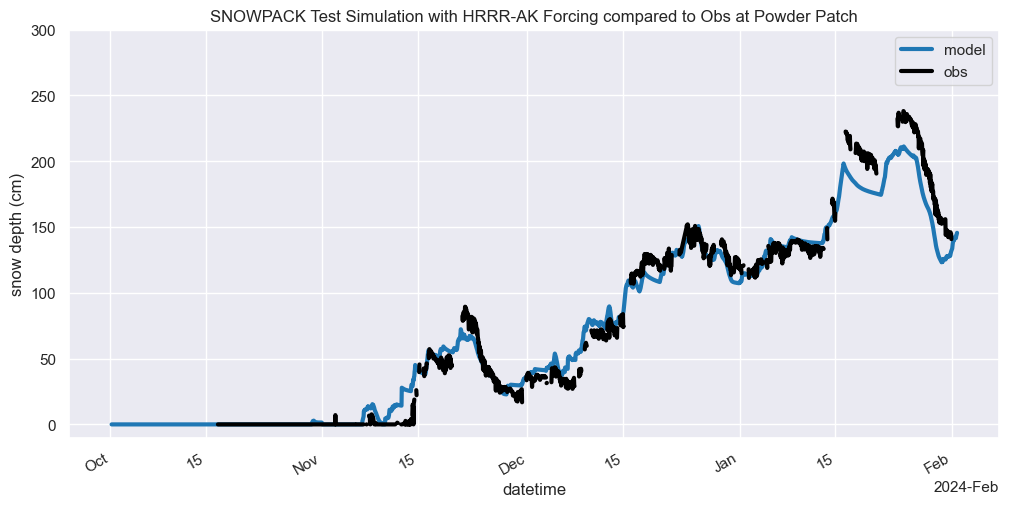

In [9]:
ds_snowpack.HS_mod.plot(label = 'model', linewidth = 3, color='tab:blue')
df_met.hs.plot(label = 'obs', linewidth = 3, color='black')

plt.title('SNOWPACK Test Simulation with HRRR-AK Forcing compared to Obs at Powder Patch')
plt.legend()

plt.ylim([-10, 300])

plt.ylabel('snow depth (cm)')

# Open Snow-17 Test Case for Test1/ to Compare

In [10]:
# /home/cassie/python/models/run_snow17/test1/output/output.snow17bmi.hrrrak_ppsa2_test1.txt
filepath = '/home/cassie/python/models/run_snow17/test1/output/'
filename = 'output.snow17bmi.hrrrak_ppsa2_test1.txt'

fullpath = os.path.join(filepath, filename)

# df_snow17 = pd.read_csv(fullpath) # use delimiter = '\t' or ',' if comma-separated 
df_snow17 = pd.read_csv(fullpath, sep=r'\s+', header=0) # using delim_whitespaced worked for the header, this is needed for the data to separate correctly

df_snow17.head()

,year,mo,dy,hr,tair,precip,precip*scf,sneqv,snowh,raim
0,2023,10,1,5,2.48,3.600,6.480,0.0,0.0,3.600
1,2023,10,1,6,2.44,2.160,3.888,0.0,0.0,2.160
2,2023,10,1,7,2.80,1.440,2.592,0.0,0.0,1.440
3,2023,10,1,8,2.49,4.320,7.776,0.0,0.0,4.320
4,2023,10,1,9,2.74,2.556,4.601,0.0,0.0,2.556


In [11]:
# change the name 'mo' to 'month, 'dy' to 'day', 'hr' to 'hour'
df_snow17.rename(columns={'mo':'month', 'dy':'day', 'hr':'hour'}, inplace=True)
df_snow17.head()

# now, create a datetime object from the year, month, day, hour, minute columns
df_snow17['datetime'] = pd.to_datetime(df_snow17[['year', 'month', 'day', 'hour']])
# index by datetime 
df_snow17.set_index('datetime', inplace=True)
df_snow17.head()

,year,month,day,hour,tair,precip,precip*scf,sneqv,snowh,raim
datetime,,,,,,,,,,
2023-10-01 05:00:00,2023,10,1,5,2.48,3.600,6.480,0.0,0.0,3.600
2023-10-01 06:00:00,2023,10,1,6,2.44,2.160,3.888,0.0,0.0,2.160
2023-10-01 07:00:00,2023,10,1,7,2.80,1.440,2.592,0.0,0.0,1.440
2023-10-01 08:00:00,2023,10,1,8,2.49,4.320,7.776,0.0,0.0,4.320
2023-10-01 09:00:00,2023,10,1,9,2.74,2.556,4.601,0.0,0.0,2.556


<Axes: xlabel='datetime'>

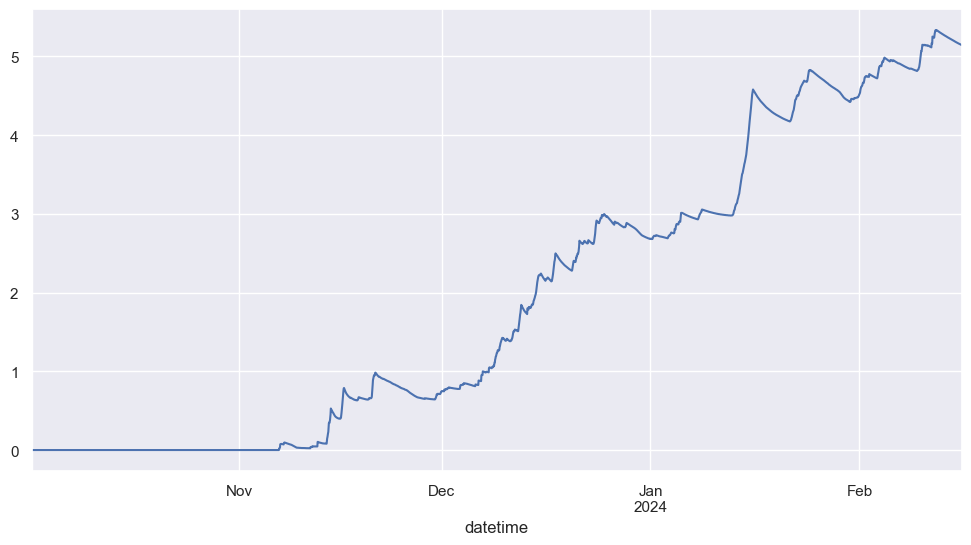

In [12]:
df_snow17.snowh.plot()

This looks like meters...?

I do not understand what the units are on these Snow17 Simulations

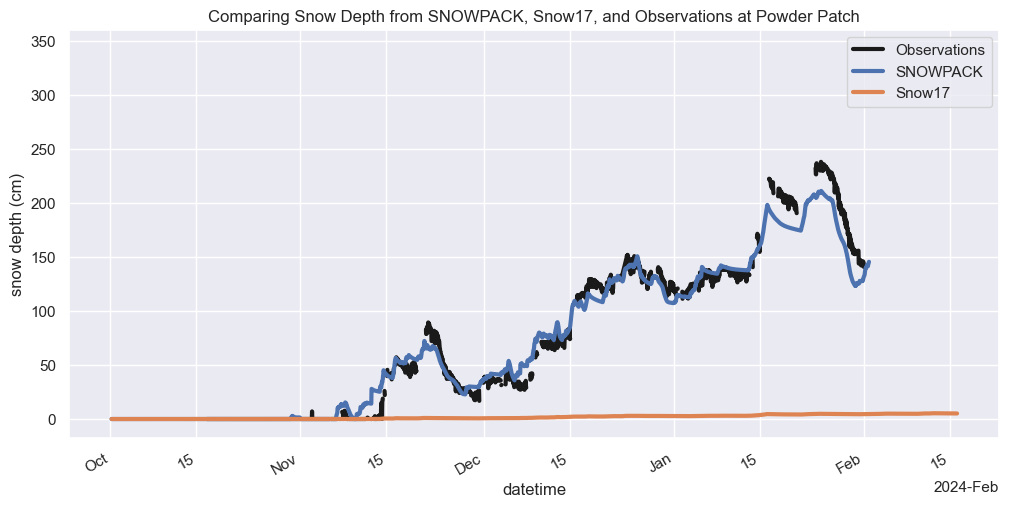

In [13]:
df_met.hs.plot(label = 'Observations', linewidth = 3, color = 'k')
ds_snowpack.HS_mod.plot(label = 'SNOWPACK', linewidth = 3)
(df_snow17.snowh).plot(label = 'Snow17', linewidth = 3)

plt.title('Comparing Snow Depth from SNOWPACK, Snow17, and Observations at Powder Patch')
plt.legend()

# plt.ylim([-10, 300])

plt.ylabel('snow depth (cm)')
plt.show()

So if it's in meters, multiply by 100

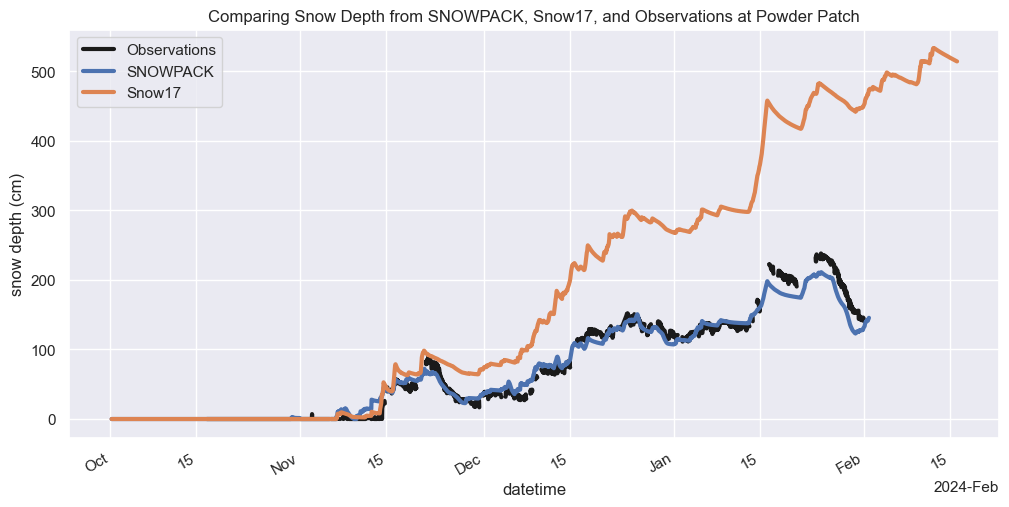

In [14]:
df_met.hs.plot(label = 'Observations', linewidth = 3, color = 'k')
ds_snowpack.HS_mod.plot(label = 'SNOWPACK', linewidth = 3)
(df_snow17.snowh*100).plot(label = 'Snow17', linewidth = 3)

plt.title('Comparing Snow Depth from SNOWPACK, Snow17, and Observations at Powder Patch')
plt.legend()

# plt.ylim([-10, 300])

plt.ylabel('snow depth (cm)')
plt.show()

If we multiply it by a factor of something, like 20/50, 

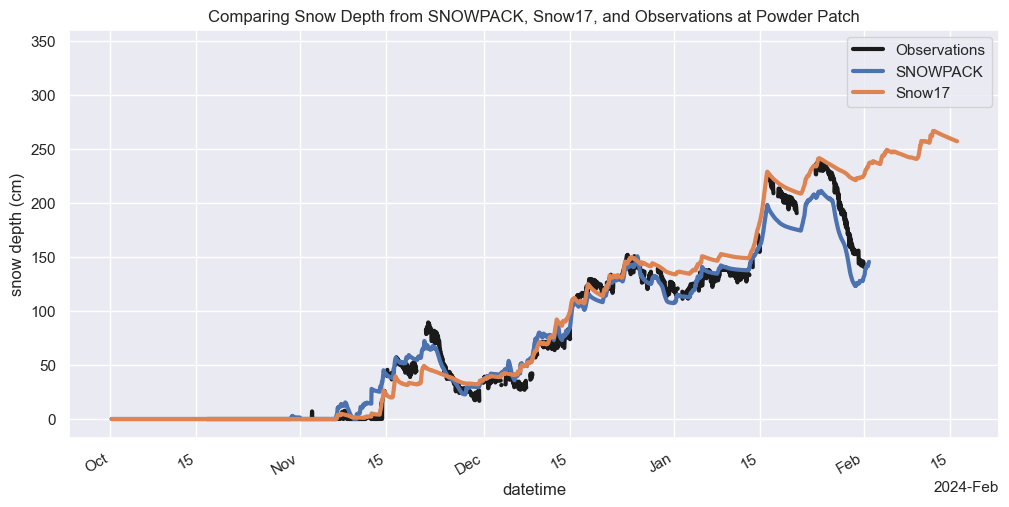

In [21]:
df_met.hs.plot(label = 'Observations', linewidth = 3, color = 'k')
ds_snowpack.HS_mod.plot(label = 'SNOWPACK', linewidth = 3)
# (df_snow17.snowh*50).plot(label = 'Snow17', linewidth = 3)
((df_snow17.snowh*100)/2).plot(label = 'Snow17', linewidth = 3)

plt.title('Comparing Snow Depth from SNOWPACK, Snow17, and Observations at Powder Patch')
plt.legend()

# plt.ylim([-10, 300])

plt.ylabel('snow depth (cm)')
plt.show()

Let's look at SWE instead, 

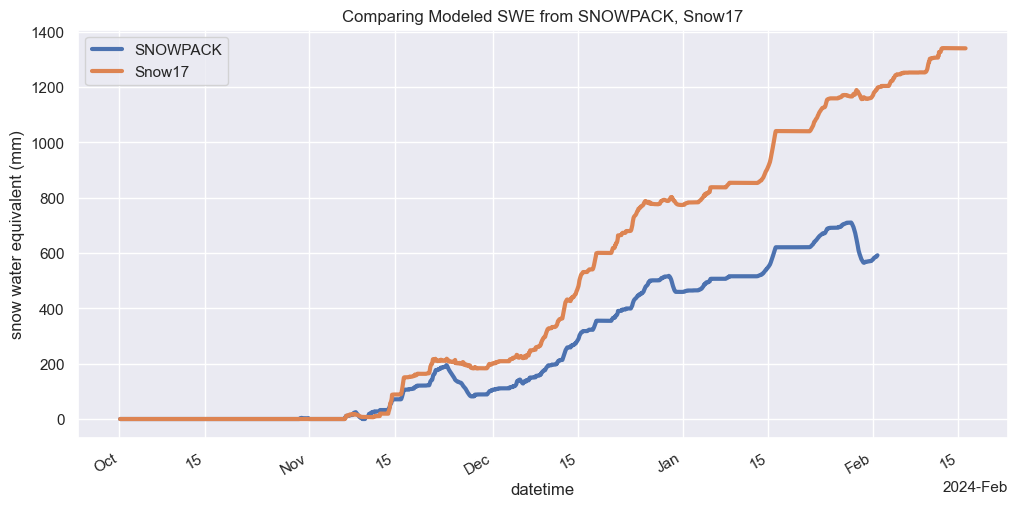

In [16]:
# SWE
ds_snowpack.SWE.plot(label = 'SNOWPACK', linewidth = 3)
(df_snow17.sneqv).plot(label = 'Snow17', linewidth = 3)

plt.title('Comparing Modeled SWE from SNOWPACK, Snow17')
plt.legend()

# plt.ylim([-10, 300])

plt.ylabel('snow water equivalent (mm)')
plt.show()

## Trying to understand Snow17 Model Output 

In [17]:
df_snow17.head()

,year,month,day,hour,tair,precip,precip*scf,sneqv,snowh,raim
datetime,,,,,,,,,,
2023-10-01 05:00:00,2023,10,1,5,2.48,3.600,6.480,0.0,0.0,3.600
2023-10-01 06:00:00,2023,10,1,6,2.44,2.160,3.888,0.0,0.0,2.160
2023-10-01 07:00:00,2023,10,1,7,2.80,1.440,2.592,0.0,0.0,1.440
2023-10-01 08:00:00,2023,10,1,8,2.49,4.320,7.776,0.0,0.0,4.320
2023-10-01 09:00:00,2023,10,1,9,2.74,2.556,4.601,0.0,0.0,2.556


*Snow17 Output*
| Variable | Meaning    | Typical units                               |
| -------- | ---------- | ------------------------------------------- |
| `tair  ` | temp       | degree C                                    |
| `precip` | precip     | mm per timestep (hour)                      |
| `sneqv`  | SWE        | mm                                          |
| `snowh`  | Snow depth | **meters** or **inches** depending on build |

based on our values of `sneqv` from 0-3, then it's likely in meters.

Since Snow-17 is not a physical snowpack model, and snow depth is a diagnostic variable derived from SWE using a simple density assumption.\
Maybe it's something like, snow depth = modeled SWE / constant snow density\
Not positive... 


#### Create our own snow depth, with any density and modeled SWE 

1 mm SWE = 1 kg/m² water\
HS (m) = SWE (kg/m²) / ρsnow (kg/m³)\
SWE (kg/m²) = SWE (mm)\

In [18]:
# we can make our own variable for snow depth which is calcualted by a density we decide 
rho_snow = 300  # snow density in kg/m3
df_snow17['HS_calc_cm'] = df_snow17['sneqv'] * (100 / rho_snow)

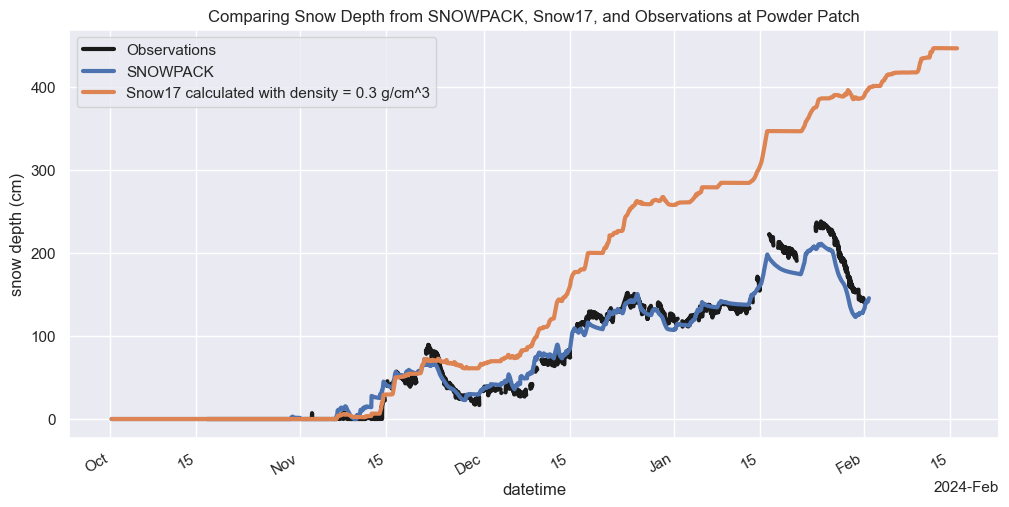

In [19]:
df_met.hs.plot(label = 'Observations', linewidth = 3, color = 'k')
ds_snowpack.HS_mod.plot(label = 'SNOWPACK', linewidth = 3)
df_snow17.HS_calc_cm.plot(label = 'Snow17 calculated with density = 0.3 g/cm^3', linewidth = 3)

plt.title('Comparing Snow Depth from SNOWPACK, Snow17, and Observations at Powder Patch')
plt.legend()

# plt.ylim([-10, 300])

plt.ylabel('snow depth (cm)')
plt.show()

That looks bad still. 

I did test the precip input, and it's certainly not that. 